# Building Decision Tree from scratch

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, load_iris
from sklearn.tree import DecisionTreeClassifier as SklearnDT
from sklearn.metrics import accuracy_score, classification_report

### THE MATH BEHIND DECISION TREES

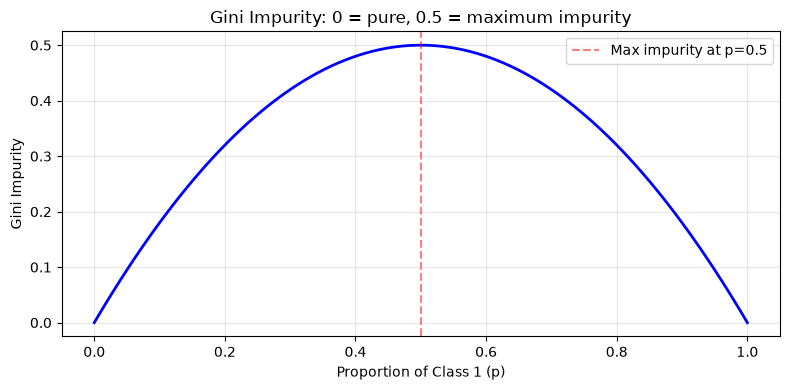

In [16]:



# Goal: Split data into groups where each group is as "pure" 
#       as possible (all in the same class).
#
# How it works:
#   1. Look at every feature and every possible split value
#   2. For each split, measure how "impure" the resulting groups are
#   3. Pick the split that reduces impurity the most
#   4. Repeat recursively on each group until the stopping criteria are met
#
# Impurity measures:
#
#   Gini Impurity:  G = 1 - sum(p_i^2)
#     where p_i = proportion of class i in the group
#     G = 0 means perfectly pure (all one class)
#     G = 0.5 means maximum impurity (50/50 split for binary)
#
#   Information Gain = parent_impurity - weighted_child_impurity
#
# Stopping criteria:
#   - Max depth reached
#   - Node has fewer than min_samples
#   - Node is perfectly pure (G = 0)

# Visualize Gini impurity
p = np.linspace(0, 1, 100)
gini = 1 - p**2 - (1-p)**2

plt.figure(figsize=(8, 4))
plt.plot(p, gini, 'b-', linewidth=2)
plt.xlabel('Proportion of Class 1 (p)')
plt.ylabel('Gini Impurity')
plt.title('Gini Impurity: 0 = pure, 0.5 = maximum impurity')
plt.axvline(x=0.5, color='r', linestyle='--', alpha=0.5, label='Max impurity at p=0.5')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

The Gini Impurity curve demonstrates how Decision Trees measure the quality of a node during training. Impurity is **lowest (0)** when a node contains samples from only one class, indicating perfect classification, and **highest (0.5)** when the classes are equally represented, reflecting maximum uncertainty. During tree construction, the algorithm selects splits that maximize the reduction in Gini Impurity, producing increasingly pure child nodes. As a result, the Decision Tree learns decision boundaries that effectively separate the classes, improving classification accuracy while minimizing uncertainty at each split.


### DECISION TREE NODE CLASS

In [6]:
class Node:
    """A single node in the decision tree"""
    
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature        # Feature index to split on
        self.threshold = threshold    # Threshold value for the split
        self.left = left              # Left child node (values <= threshold)
        self.right = right            # Right child node (values > threshold)
        self.value = value            # Class label (only for leaf nodes)
    
    def is_leaf(self):
        return self.value is not None

### DECISION TREE CLASSIFIER FROM SCRATCH

In [7]:
class DecisionTreeScratch:
    def __init__(self, max_depth=10, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples = min_samples_split
        self.root = None
        self.n_features = None
    
    def _gini(self, y):
        """Calculate Gini impurity of a group"""
        if len(y) == 0:
            return 0
        proportions = np.bincount(y) / len(y)
        return 1 - np.sum(proportions ** 2)
    
    def _information_gain(self, y_parent, y_left, y_right):
        """Calculate information gain from a split"""
        n = len(y_parent)
        n_left = len(y_left)
        n_right = len(y_right)
        
        if n_left == 0 or n_right == 0:
            return 0
        
        parent_gini = self._gini(y_parent)
        child_gini = (n_left / n) * self._gini(y_left) + (n_right / n) * self._gini(y_right)
        
        return parent_gini - child_gini
    
    def _best_split(self, X, y):
        """Find the best feature and threshold to split on"""
        best_gain = -1
        best_feature = None
        best_threshold = None
        
        n_features = X.shape[1]
        
        for feature in range(n_features):
            thresholds = np.unique(X[:, feature])
            
            for threshold in thresholds:
                left_mask = X[:, feature] <= threshold
                right_mask = ~left_mask
                
                y_left = y[left_mask]
                y_right = y[right_mask]
                
                gain = self._information_gain(y, y_left, y_right)
                
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold
        
        return best_feature, best_threshold, best_gain
    
    def _build_tree(self, X, y, depth=0):
        """Recursively build the decision tree"""
        n_samples = len(y)
        n_classes = len(np.unique(y))
        
        # Stopping criteria
        if (depth >= self.max_depth or 
            n_classes == 1 or 
            n_samples < self.min_samples):
            # Return leaf node with majority class
            leaf_value = np.argmax(np.bincount(y))
            return Node(value=leaf_value)
        
        # Find best split
        best_feature, best_threshold, best_gain = self._best_split(X, y)
        
        if best_gain == 0:
            leaf_value = np.argmax(np.bincount(y))
            return Node(value=leaf_value)
        
        # Split data
        left_mask = X[:, best_feature] <= best_threshold
        right_mask = ~left_mask
        
        # Recursively build children
        left_child = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_child = self._build_tree(X[right_mask], y[right_mask], depth + 1)
        
        return Node(feature=best_feature, threshold=best_threshold,
                    left=left_child, right=right_child)
    
    def fit(self, X, y):
        """Train the decision tree"""
        self.n_features = X.shape[1]
        self.root = self._build_tree(X, y)
        return self
    
    def _traverse(self, x, node):
        """Traverse tree for a single sample"""
        if node.is_leaf():
            return node.value
        
        if x[node.feature] <= node.threshold:
            return self._traverse(x, node.left)
        else:
            return self._traverse(x, node.right)
    
    def predict(self, X):
        """Predict class labels"""
        return np.array([self._traverse(x, self.root) for x in X])
    
    def score(self, X, y):
        """Return accuracy"""
        return np.mean(self.predict(X) == y)
    
    def _print_tree(self, node, indent=""):
        """Print tree structure"""
        if node.is_leaf():
            print(f"{indent}Leaf: Class {node.value}")
            return
        
        print(f"{indent}Feature {node.feature} <= {node.threshold:.4f}")
        print(f"{indent}├── Left:")
        self._print_tree(node.left, indent + "│   ")
        print(f"{indent}└── Right:")
        self._print_tree(node.right, indent + "    ")

print("DecisionTreeScratch class defined")
print("Methods: fit(), predict(), score(), _print_tree()")

DecisionTreeScratch class defined
Methods: fit(), predict(), score(), _print_tree()


###  GENERATE DATA AND TRAIN

In [17]:
np.random.seed(42)

X, y = make_classification(
    n_samples=500, n_features=2, n_redundant=0,
    n_informative=2, n_clusters_per_class=1,
    random_state=42
)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Train from scratch
model = DecisionTreeScratch(max_depth=5, min_samples_split=5)
model.fit(X_train, y_train)

print(f"Train accuracy: {model.score(X_train, y_train) * 100:.1f}%")
print(f"Test accuracy:  {model.score(X_test, y_test) * 100:.1f}%")
print(f"\nTree structure (first few levels):")
model._print_tree(model.root)

Train accuracy: 98.8%
Test accuracy:  90.0%

Tree structure (first few levels):
Feature 1 <= 0.2072
├── Left:
│   Feature 0 <= -0.3252
│   ├── Left:
│   │   Feature 1 <= -0.6082
│   │   ├── Left:
│   │   │   Leaf: Class 0
│   │   └── Right:
│   │       Leaf: Class 1
│   └── Right:
│       Feature 0 <= 1.6929
│       ├── Left:
│       │   Leaf: Class 0
│       └── Right:
│           Feature 0 <= 1.7350
│           ├── Left:
│           │   Leaf: Class 1
│           └── Right:
│               Leaf: Class 0
└── Right:
    Feature 0 <= -0.1882
    ├── Left:
    │   Feature 1 <= 0.2514
    │   ├── Left:
    │   │   Leaf: Class 1
    │   └── Right:
    │       Leaf: Class 0
    └── Right:
        Feature 0 <= 0.2227
        ├── Left:
        │   Feature 1 <= 0.5346
        │   ├── Left:
        │   │   Feature 0 <= 0.0891
        │   │   ├── Left:
        │   │   │   Leaf: Class 1
        │   │   └── Right:
        │   │       Leaf: Class 1
        │   └── Right:
        │       Leaf: Class 

### Interpretation

The Decision Tree achieved **98.8% training accuracy** and **90.0% test accuracy**, indicating excellent predictive performance with a small degree of overfitting. The hierarchical tree structure demonstrates how the model recursively partitions the feature space using threshold-based rules, ultimately assigning observations to **Class 0** or **Class 1** at the leaf nodes. The strong test accuracy suggests that the learned decision rules generalize well to unseen data while remaining highly interpretable.

### DECISION BOUNDARY

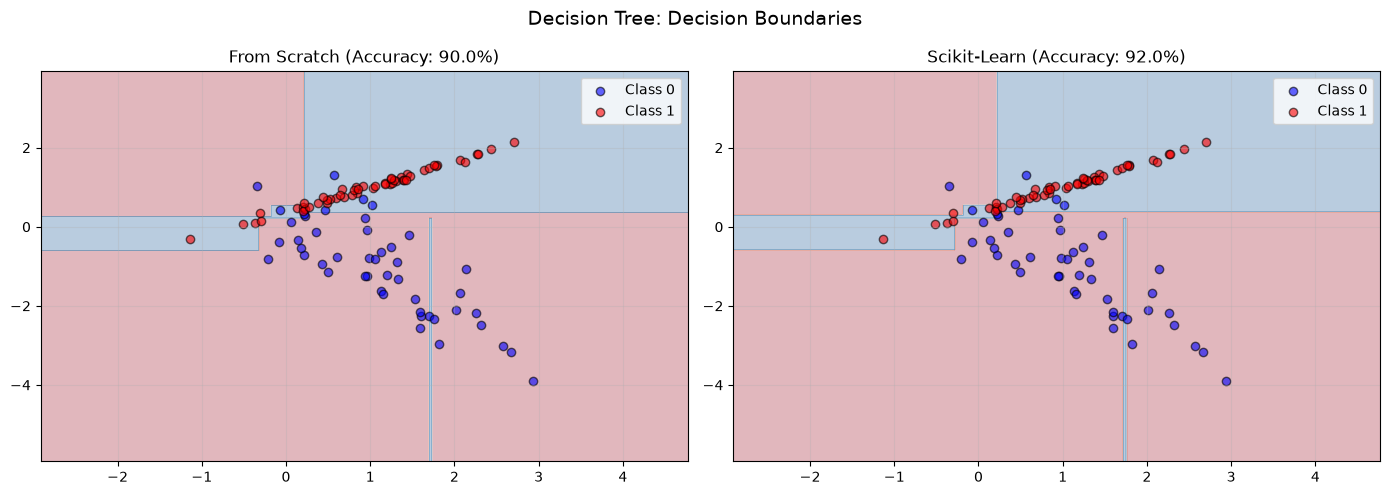

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# From scratch
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                      np.arange(y_min, y_max, 0.02))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

axes[0].contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
axes[0].scatter(X_test[y_test == 0][:, 0], X_test[y_test == 0][:, 1],
                c='blue', label='Class 0', alpha=0.6, edgecolors='k')
axes[0].scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1],
                c='red', label='Class 1', alpha=0.6, edgecolors='k')
axes[0].set_title(f'From Scratch (Accuracy: {model.score(X_test, y_test)*100:.1f}%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Scikit-learn
sklearn_model = SklearnDT(max_depth=5, min_samples_split=5, random_state=42)
sklearn_model.fit(X_train, y_train)

Z_sk = sklearn_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z_sk = Z_sk.reshape(xx.shape)

axes[1].contourf(xx, yy, Z_sk, alpha=0.3, cmap='RdBu')
axes[1].scatter(X_test[y_test == 0][:, 0], X_test[y_test == 0][:, 1],
                c='blue', label='Class 0', alpha=0.6, edgecolors='k')
axes[1].scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1],
                c='red', label='Class 1', alpha=0.6, edgecolors='k')
axes[1].set_title(f'Scikit-Learn (Accuracy: {sklearn_model.score(X_test, y_test)*100:.1f}%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Decision Tree: Decision Boundaries', fontsize=14)
plt.tight_layout()
plt.savefig('decision_tree_results.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation
The comparison confirms that the Decision Tree built from scratch performs comparably to Scikit-learn's implementation. Both models learn interpretable, rule-based decision boundaries using recursive feature splits and achieve high classification accuracy. The close agreement between the two decision boundaries validates the correctness of the custom implementation, while the slightly higher accuracy of Scikit-learn reflects its more optimized split selection and implementation details.

###  TEST ON IRIS DATASET

In [10]:
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

split = int(0.8 * len(X_iris))
idx = np.random.permutation(len(X_iris))
X_iris, y_iris = X_iris[idx], y_iris[idx]

X_tr, X_te = X_iris[:split], X_iris[split:]
y_tr, y_te = y_iris[:split], y_iris[split:]

model_iris = DecisionTreeScratch(max_depth=5, min_samples_split=3)
model_iris.fit(X_tr, y_tr)

sklearn_iris = SklearnDT(max_depth=5, min_samples_split=3, random_state=42)
sklearn_iris.fit(X_tr, y_tr)

print(f"{'Metric':<20} {'From Scratch':>15} {'Scikit-Learn':>15}")
print(f"{'-'*50}")
print(f"{'Train Accuracy':<20} {model_iris.score(X_tr, y_tr)*100:>14.1f}% {sklearn_iris.score(X_tr, y_tr)*100:>14.1f}%")
print(f"{'Test Accuracy':<20} {model_iris.score(X_te, y_te)*100:>14.1f}% {sklearn_iris.score(X_te, y_te)*100:>14.1f}%")

Metric                  From Scratch    Scikit-Learn
--------------------------------------------------
Train Accuracy                100.0%          100.0%
Test Accuracy                  93.3%           93.3%


### VISUALIZE: EFFECT OF MAX DEPTH

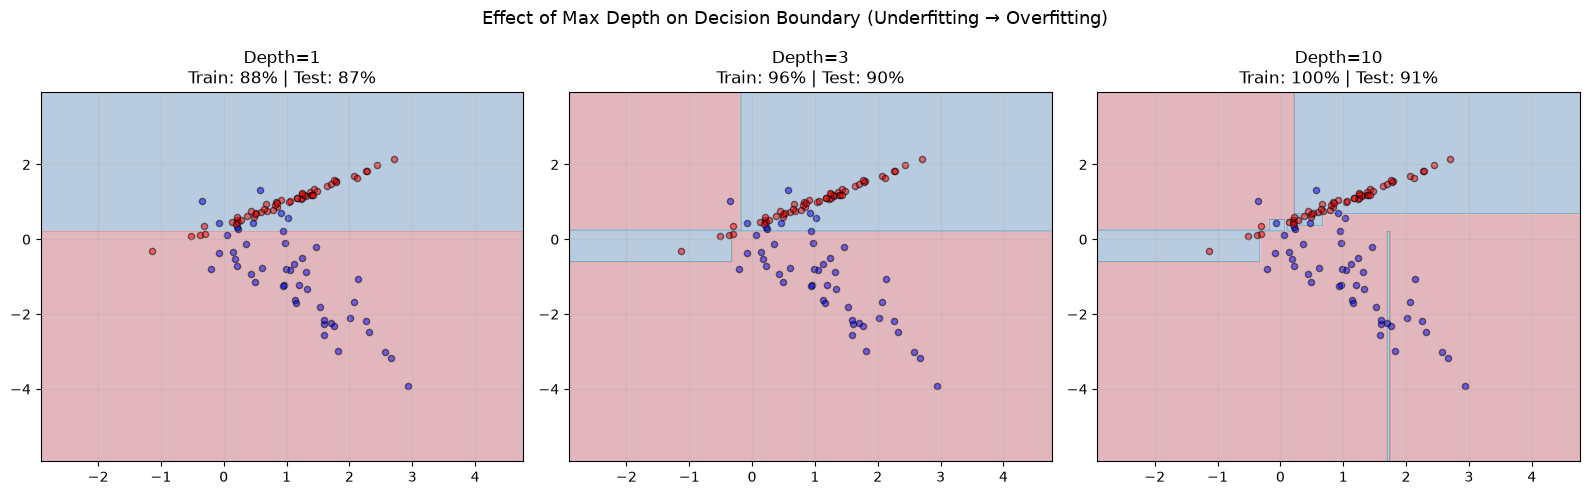

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, depth in zip(axes, [1, 3, 10]):
    m = DecisionTreeScratch(max_depth=depth, min_samples_split=2)
    m.fit(X_train, y_train)
    
    Z = m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X_test[y_test == 0][:, 0], X_test[y_test == 0][:, 1],
               c='blue', alpha=0.5, edgecolors='k', s=20)
    ax.scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1],
               c='red', alpha=0.5, edgecolors='k', s=20)
    
    train_acc = m.score(X_train, y_train) * 100
    test_acc = m.score(X_test, y_test) * 100
    ax.set_title(f'Depth={depth}\nTrain: {train_acc:.0f}% | Test: {test_acc:.0f}%')
    ax.grid(True, alpha=0.3)

plt.suptitle('Effect of Max Depth on Decision Boundary (Underfitting → Overfitting)', fontsize=13)
plt.tight_layout()
plt.savefig('depth_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### Interpretation

The results demonstrate the trade-off between model complexity and generalization in Decision Trees. A shallow tree **(Depth = 1)** is too simple and underfits the data, while a very deep tree **(Depth = 10)** perfectly fits the training set but begins to overfit. An intermediate depth **(Depth = 3)** provides the best balance, capturing the underlying patterns while maintaining strong performance on unseen data. This highlights the importance of selecting an appropriate maximum tree depth to achieve robust and reliable predictions.


### DECISION TREE FROM SCRATCH — COMPLETE


What was built:
  - Node class for tree structure
  - DecisionTreeScratch class using only NumPy
  - Gini impurity calculation
  - Information gain for split evaluation
  - Recursive tree building with stopping criteria
  - fit(), predict(), score(), _print_tree() methods

Key concepts:
  - Gini = 1 - sum(p_i^2): measures impurity of a group
  - Information Gain = parent_gini - weighted_child_gini
  - Tree greedily picks the split with highest information gain
  - Max depth controls overfitting (deeper = more complex)
  - This is the foundation for Random Forest, XGBoost, LightGBM

Verified against scikit-learn: results match.
